ASONAM

- Los casos de rabia van a ser nodos nuevamente.
- Se va a crear una relacion bidireccional de proximidad desde las cuadras hacia puestos de salud, torrenteras, casos de rabia pero se pone como atributo de la relacion la distancia.
- Para las etiquetas solo se tomara en cuenta los casos de vacunacion que esten dentro de una cuadra y solo tendra como relacion con esa cuadra y la distancia 0.
- Los casos de rabia que no esten dentro de una cuadra se creara una relacion de proximidad con el atributo de distancia
- Se separaran lo datos del 2015 hasta el 2018 para entrenamiento, para validacion 2019 hasta el 2020 y test 2021 hasta 2023 
- Vamos a crear un grafo por año

Posiblemente se agregara despues
- clusterizacion con kmeans
- cross validation

In [320]:
pip install pyreadr pandas torch fastkml torch_geometric folium geopandas k_means_constrained matplotlib

Note: you may need to restart the kernel to use updated packages.


In [321]:
import pandas as pd

In [322]:
# PUESTOS DE SALUD
df_health_posts = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Health_centers_AQP/Puestos_de_salud_APQ_12ene2024.csv", sep=";")
print(df_health_posts.shape)
df_health_posts.head()

(83, 11)


,cluster,n_microred,microred,name,lat,long,y_proj,x_proj,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,22.0,20,MARITZA CAMPOS,C.S. MARITZA CAMPO DIAZ,-16.351375,-71.562525,-1935159.862,2835969.968,NaN,NaN,NaN
1,26.0,20,MARITZA CAMPOS,P.S. CIUDAD MUNICIPAL,-16.325474,-71.594062,-1931722.877,2832729.607,NaN,NaN,NaN
2,22.0,20,MARITZA CAMPOS,P.S. PERUARBO,-16.345310,-71.600061,-1933977.297,2831792.294,NaN,NaN,NaN
3,24.0,20,MARITZA CAMPOS,P.S. NAZARENO,-16.328171,-71.549513,-1932597.555,2837747.160,NaN,NaN,NaN
4,5.0,1,FRANCISCO BOLOGNESI,C.S. FRANCISCO BOLOGNESI,-16.354767,-71.542092,-1935814.847,2838243.050,NaN,NaN,NaN


In [323]:
# TORRENTERAS
df_water_channels = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Water_channels_AQP/Hidrografia_AQP_18ene2024.csv", sep=";")
df_water_channels.head()

,type,ident,lat,long,y_proj,x_proj
0,Rios_Principales,r_prin_001,,,-1.516416e+00,2.076337e+07
1,Rios_Principales,r_prin_001,-16.30381616,-71.48611168,-1.930532e+06,2.845257e+06
2,Rios_Principales,r_prin_001,-16.30379005,-71.48621225,-1.930528e+06,2.845246e+06
3,Rios_Principales,r_prin_001,-16.30376392,-71.48631287,-1.930523e+06,2.845235e+06
4,Rios_Principales,r_prin_001,-16.30376396,-71.48641297,-1.930522e+06,2.845224e+06


In [324]:
#  NIVEL SOCIO-ECONOMICO
df_economic_income_1 = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Economic_income_AQP/Economic_income_cluster/Ecom_cluster_22_10may2023.csv", sep=";")
print(df_economic_income_1.shape)
df_economic_income_2 = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Economic_income_AQP/Economic_income_cluster/Ecom_cluster_23_21feb2023.csv", sep=";")
print(df_economic_income_2.shape)
df_economic_income_3 = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Economic_income_AQP/Economic_income_cluster/Ecom_cluster_24_21feb2023.csv", sep=";")
print(df_economic_income_3.shape)
df_economic_income_4 = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Economic_income_AQP/Economic_income_cluster/Ecom_cluster_25_21feb2023.csv", sep=";")
print(df_economic_income_4.shape)
df_economic_income_5 = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Economic_income_AQP/Economic_income_cluster/Ecom_cluster_26_21feb2023.csv", sep=";")
print(df_economic_income_5.shape)
df_economic_income_6 = pd.read_csv("~/Descargas/SPATIAL_DATA_AQP/Economic_income_AQP/Economic_income_cluster/Ecom_cluster_27_21feb2023.csv", sep=";")
print(df_economic_income_6.shape)


# Limpiar los nombres de las columnas
dfs = [
    df_economic_income_1,
    df_economic_income_2,
    df_economic_income_3,
    df_economic_income_4,
    df_economic_income_5,
    df_economic_income_6
]
for df in dfs:
    df.columns = df.columns.str.strip()

df_economic_income = pd.concat(dfs, ignore_index=True)
print(f"Union de todos los archivos donde se encuentran los puntos que crean el poligono de la cuadra: {df_economic_income.shape}")
df_economic_income.head()

(6331, 6)
(3683, 6)
(2832, 6)
(2268, 6)
(3178, 6)
(6748, 6)
Union de todos los archivos donde se encuentran los puntos que crean el poligono de la cuadra: (25040, 6)


,ident,lat,long,y_proj,x_proj,ingreso_economico
0,1.4.54-1,,,-1.516416e+00,2.076337e+07,B
1,1.4.54-1,-16.3619287,-71.56312249,-1.936392e+06,2.835765e+06,B
2,1.4.54-1,-16.36042421,-71.56334575,-1.936212e+06,2.835759e+06,B
3,1.4.54-1,-16.36114067,-71.56646806,-1.936257e+06,2.835396e+06,B
4,1.4.54-1,-16.36256118,-71.5660744,-1.936429e+06,2.835422e+06,B


In [325]:
df_economic_income["ingreso_economico"].value_counts(dropna=False)

ingreso_economico
E      14985
D       6138
NaN     2045
C       1570
B        302
Name: count, dtype: int64

In [326]:
# RABIA
import os
import xml.etree.ElementTree as ET
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# Ruta a la carpeta con archivos KML
folder_path = "/home/pantro/Descargas/KML_casos_rabia/"
kml_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".kml")])

# Namespace usado en KML
ns = {"kml": "http://www.opengis.net/kml/2.2"}

features = []

for filename in kml_files:
    print(f"Nombre del archivo: {filename}")
    filepath = os.path.join(folder_path, filename)
    try:
        year = int(filename.replace(".kml", "").split("_")[-1]) # Nombre de los archivos "Casos_de_Rabia_2015.kml"
        print(f"Año del archivo: {year}")
    except ValueError:
        continue  # omite archivos mal nombrados

    tree = ET.parse(filepath)
    root = tree.getroot()

    placemarks = root.findall(".//kml:Placemark", ns)
    for pm in placemarks:
        coord_tag = pm.find(".//kml:coordinates", ns)
        name_tag = pm.find("kml:name", ns)
        if coord_tag is not None:
            coords_text = coord_tag.text.strip()
            try:
                lon, lat, *_ = map(float, coords_text.split(','))
                name = name_tag.text.strip() if name_tag is not None else None
                features.append({
                    "name": name,
                    "anio": year,
                    "geometry": Point(lon, lat),
                })
            except ValueError:
                continue

# Crear GeoDataFrame
gdf_rabies = gpd.GeoDataFrame(features, crs="EPSG:4326")

# Mostrar
print(gdf_rabies.shape)
gdf_rabies.head()

# Si quieres guardar como GeoJSON
# gdf.to_file("casos_rabia_completo.geojson", driver="GeoJSON")

Nombre del archivo: Casos_de_Rabia_2015.kml
Año del archivo: 2015
Nombre del archivo: Casos_de_Rabia_2016.kml
Año del archivo: 2016
Nombre del archivo: Casos_de_Rabia_2017.kml
Año del archivo: 2017
Nombre del archivo: Casos_de_Rabia_2018.kml
Año del archivo: 2018
Nombre del archivo: Casos_de_Rabia_2019.kml
Año del archivo: 2019
Nombre del archivo: Casos_de_Rabia_2020.kml
Año del archivo: 2020
Nombre del archivo: Casos_de_Rabia_2021.kml
Año del archivo: 2021
Nombre del archivo: Casos_de_Rabia_2022.kml
Año del archivo: 2022
Nombre del archivo: Casos_de_Rabia_2023.kml
Año del archivo: 2023
Nombre del archivo: Casos_de_Rabia_2024.kml
Año del archivo: 2024
Nombre del archivo: Casos_de_Rabia_2025 .kml
Año del archivo: 2025
(399, 3)


,name,anio,geometry
0,53,2015,POINT (-71.51186 -16.36774)
1,73,2015,POINT (-71.50151 -16.37566)
2,92,2015,POINT (-71.50128 -16.39534)
3,101,2015,POINT (-71.52681 -16.41053)
4,103,2015,POINT (-71.51339 -16.40597)


## Preprosesamiento

In [327]:
import pandas as pd
import geopandas as gpd
import torch
from torch_geometric.data import HeteroData
from geopy.distance import geodesic
from shapely.geometry import Point, Polygon, LineString

In [328]:
# PUESTOS DE SALUD
# Suponiendo que df_health_posts tiene columnas 'lat' y 'long'
gdf_health_posts = gpd.GeoDataFrame(
    df_health_posts,
    geometry=gpd.points_from_xy(df_health_posts['long'], df_health_posts['lat']),
    crs="EPSG:4326"
)
# Filtrar filas: asegurarse que 'cluster' sea un número (ignorar NaNs o strings)
gdf_health_posts = gdf_health_posts[pd.to_numeric(gdf_health_posts['cluster'], errors='coerce').notnull()]

# Convertir 'cluster' a numérico si aún no lo es
gdf_health_posts['cluster'] = gdf_health_posts['cluster'].astype(int)

# Seleccionar solo las columnas deseadas
gdf_health_posts = gdf_health_posts[['cluster', 'n_microred', 'name', 'lat', 'long', 'geometry']]
print(gdf_health_posts.shape)
gdf_health_posts.head()

(77, 6)


,cluster,n_microred,name,lat,long,geometry
0,22,20,C.S. MARITZA CAMPO DIAZ,-16.351375,-71.562525,POINT (-71.56252 -16.35137)
1,26,20,P.S. CIUDAD MUNICIPAL,-16.325474,-71.594062,POINT (-71.59406 -16.32547)
2,22,20,P.S. PERUARBO,-16.345310,-71.600061,POINT (-71.60006 -16.34531)
3,24,20,P.S. NAZARENO,-16.328171,-71.549513,POINT (-71.54951 -16.32817)
4,5,1,C.S. FRANCISCO BOLOGNESI,-16.354767,-71.542092,POINT (-71.54209 -16.35477)


In [329]:
# TORRENTERAS
# Eliminar filas vacías (sin coordenadas)
df_water_channels_clean = df_water_channels[
    (df_water_channels["lat"].str.strip() != '') &
    (df_water_channels["long"].str.strip() != '')
]
# Crear geometrías LineString por grupo
lineas = (
    df_water_channels_clean.groupby("ident")
    .apply(lambda group: LineString(zip(group["long"], group["lat"])))
    .reset_index(name="geometry")
)

# Convertir a GeoDataFrame
gdf_water_channels = gpd.GeoDataFrame(lineas, geometry="geometry", crs="EPSG:4326")
print(gdf_water_channels.shape)
gdf_water_channels.head()

/tmp/ipykernel_18260/627060655.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: LineString(zip(group["long"], group["lat"])))


(218, 2)


,ident,geometry
0,r_prin_001,"LINESTRING (-71.48611 -16.30382, -71.48621 -16..."
1,r_prin_002,"LINESTRING (-71.43686 -16.42426, -71.43687 -16..."
2,r_prin_003,"LINESTRING (-71.41278 -16.57048, -71.41280 -16..."
3,r_prin_004,"LINESTRING (-71.43694 -16.49497, -71.43696 -16..."
4,torr_001,"LINESTRING (-71.46112 -16.36777, -71.46113 -16..."


In [330]:
df_economic_income.head()

,ident,lat,long,y_proj,x_proj,ingreso_economico
0,1.4.54-1,,,-1.516416e+00,2.076337e+07,B
1,1.4.54-1,-16.3619287,-71.56312249,-1.936392e+06,2.835765e+06,B
2,1.4.54-1,-16.36042421,-71.56334575,-1.936212e+06,2.835759e+06,B
3,1.4.54-1,-16.36114067,-71.56646806,-1.936257e+06,2.835396e+06,B
4,1.4.54-1,-16.36256118,-71.5660744,-1.936429e+06,2.835422e+06,B


In [331]:
#------------------------------
# CONTRUIR EL POLIGONO DE LA CUADRA - NIVEL SOCIECONOMICO
# ------------------------------
# Eliminar filas vacías (sin coordenadas)
df_economic_income_clean = df_economic_income[
    (df_economic_income["lat"].str.strip() != '') &
    (df_economic_income["long"].str.strip() != '')
].copy()

# Agrupar por 'ident' (ID de cuadra) y construir polígonos, ya que se tienen un punto GPS por cada punto que conforma el poligono
block_polys = df_economic_income_clean.groupby("ident").apply(
    lambda g: pd.Series({
        "geometry": Polygon(zip(g["long"], g["lat"])),
        "ingreso_economico": g["ingreso_economico"].unique()[0]  # único valor
    })
).reset_index()
block_polys.columns = ["block_id", "geometry", "ingreso_economico"]

# Adicionando una columna "ingreso_economico_num" con datos numericos para poder analizar esa columna
# Optamos por cambiar los datos de letras a numeros en ves de utilizar ON-HOT ya que en one-hot no permanece el orden y en lo numero si.
# Despues se puede probar con one-hot para ver que sucede
print(block_polys["ingreso_economico"].value_counts(dropna=False))
map_dict = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5}# Mapeo de categorías a valores ordinales
block_polys["ingreso_economico_num"] = block_polys["ingreso_economico"].map(map_dict)# Crear nueva columna ordinal

# 🔹 Imputación de NaN con la moda
moda = block_polys["ingreso_economico_num"].mode()[0]
# Obtener la categoría (letra) correspondiente a la moda
reverse_map = {v: k for k, v in map_dict.items()}
moda_categoria = reverse_map[moda]

# Imputar columna numérica
block_polys["ingreso_economico_num"].fillna(moda, inplace=True)
# Imputar también la columna categórica
block_polys["ingreso_economico"].fillna(moda_categoria, inplace=True)
print("Moda utilizada para imputar:", moda)
print("Nulos después de imputar:", block_polys["ingreso_economico_num"].isnull().sum())

# Crear GeoDataFrame con polígonos
gdf_economic_income = gpd.GeoDataFrame(block_polys, geometry="geometry", crs="EPSG:4326")
print(f"Cantidad de cuadras: {gdf_economic_income.shape}")
print(gdf_economic_income["ingreso_economico"].value_counts(dropna=False))
gdf_economic_income.head()

ingreso_economico
E      2619
D      1057
NaN     366
C       213
B        41
Name: count, dtype: int64
Moda utilizada para imputar: 5.0
Nulos después de imputar: 0
Cantidad de cuadras: (4296, 4)
ingreso_economico
E    2985
D    1057
C     213
B      41
Name: count, dtype: int64


/tmp/ipykernel_18260/218429772.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  block_polys = df_economic_income_clean.groupby("ident").apply(
/tmp/ipykernel_18260/218429772.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  block_

,block_id,geometry,ingreso_economico,ingreso_economico_num
0,1.4.100-1,"POLYGON ((-71.58095 -16.35108, -71.58178 -16.3...",D,4.0
1,1.4.100-10,"POLYGON ((-71.58352 -16.34361, -71.58349 -16.3...",D,4.0
2,1.4.100-11,"POLYGON ((-71.58344 -16.34353, -71.58179 -16.3...",D,4.0
3,1.4.100-12,"POLYGON ((-71.58582 -16.34319, -71.58592 -16.3...",D,4.0
4,1.4.100-2,"POLYGON ((-71.58400 -16.34949, -71.58416 -16.3...",D,4.0


### Aplicando KmeansConstrained para agrupar cuadras

In [332]:
'''
from k_means_constrained import KMeansConstrained
import numpy as np

# Definir tamaño objetivo por cluster
target_size = 10  

# Lista para guardar resultados
frames = []

for nivel, subset in gdf_economic_income.groupby("ingreso_economico"):
    n = len(subset)
    n_clusters = int(np.ceil(n / target_size))

    # Extraer centroides para clustering espacial
    coords = np.array(list(zip(subset.geometry.centroid.x, subset.geometry.centroid.y)))

    # KMeans con restricción de tamaño
    model = KMeansConstrained(
        n_clusters=n_clusters,
        size_min=5,
        size_max=15,
        random_state=42
    )
    labels = model.fit_predict(coords)

    subset = subset.copy()
    subset["cluster_local"] = labels
    subset["cluster_global"] = [f"{nivel}_{lbl}" for lbl in labels]

    frames.append(subset)

# Concatenar resultados
gdf_clustered = gpd.GeoDataFrame(pd.concat(frames), crs=gdf_economic_income.crs)

# Construir polígonos finales
gdf_superareas = gdf_clustered.dissolve(by="cluster_global").reset_index()

print(gdf_superareas.shape)
gdf_superareas.head()
'''

'\nfrom k_means_constrained import KMeansConstrained\nimport numpy as np\n\n# Definir tamaño objetivo por cluster\ntarget_size = 10  \n\n# Lista para guardar resultados\nframes = []\n\nfor nivel, subset in gdf_economic_income.groupby("ingreso_economico"):\n    n = len(subset)\n    n_clusters = int(np.ceil(n / target_size))\n\n    # Extraer centroides para clustering espacial\n    coords = np.array(list(zip(subset.geometry.centroid.x, subset.geometry.centroid.y)))\n\n    # KMeans con restricción de tamaño\n    model = KMeansConstrained(\n        n_clusters=n_clusters,\n        size_min=5,\n        size_max=15,\n        random_state=42\n    )\n    labels = model.fit_predict(coords)\n\n    subset = subset.copy()\n    subset["cluster_local"] = labels\n    subset["cluster_global"] = [f"{nivel}_{lbl}" for lbl in labels]\n\n    frames.append(subset)\n\n# Concatenar resultados\ngdf_clustered = gpd.GeoDataFrame(pd.concat(frames), crs=gdf_economic_income.crs)\n\n# Construir polígonos finales\ngd

### MiniBatchKmeans

In [333]:
"""
Este bloque construye "superáreas" geográficas a partir de cuadras individuales,
agrupándolas según cercanía espacial y nivel socioeconómico.

Pasos principales:

1. Agrupación por nivel socioeconómico:
   Se separan las cuadras según su categoría de ingreso (ej. A=1, B=2, C=3, D=4, E=5),
   para evitar mezclar zonas de distinto perfil.

2. Clustering espacial (MiniBatchKMeans):
   - Para cada grupo socioeconómico, se calculan centroides de las cuadras.
   - Se aplica KMeans para agrupar cuadras cercanas geográficamente.
   - El número de clusters se define para que cada grupo tenga aprox. "target_size = 10" cuadras.

3. Asignación de clusters:
   - Se etiqueta cada cuadra con un cluster local y uno global
     (ej. "D_0", "D_1"), manteniendo la separación por nivel socioeconómico.

4. Unión de geometrías (dissolve):
   - Se combinan las geometrías de las cuadras dentro de cada cluster,
     formando una "superárea" (posiblemente MultiPolygon).

5. Corrección de geometrías:
   - Se aplica buffer(0) para corregir errores geométricos comunes.

6. Conversión a sistema métrico:
   - Se transforma a CRS en metros (EPSG:3857) para poder aplicar buffers correctamente.

7. Fusión de polígonos (merge_to_single_polygon):
   - Si una superárea queda como MultiPolygon:
       a) Se expanden ligeramente las partes (buffer positivo)
       b) Se unen (unary_union)
       c) Se contraen al tamaño original (buffer negativo)
   - Si aún quedan múltiples partes separadas, se selecciona la más grande.

8. Retorno a coordenadas geográficas:
   - Se vuelve a WGS84 (EPSG:4326) para visualización (ej. Folium).
"""
from sklearn.cluster import MiniBatchKMeans
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import numpy as np

# Definir tamaño objetivo (cantidad de cuadras aprox que se unen)
target_size = 10  

# Lista para guardar resultados
frames = []

for nivel, subset in gdf_economic_income.groupby("ingreso_economico"):
    n = len(subset)
    n_clusters = int(np.ceil(n / target_size))  # cuántos clusters para este grupo socioeconómico

    # Extraer centroides para clustering espacial
    coords = np.array(list(zip(subset.geometry.centroid.x, subset.geometry.centroid.y)))

    # KMeans rápido (sin restricción de tamaño exacto)
    model = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=42,
        batch_size=500
    )
    labels = model.fit_predict(coords)

    subset = subset.copy()
    subset["cluster_local"] = labels
    subset["cluster_global"] = [f"{nivel}_{lbl}" for lbl in labels]

    frames.append(subset)

# Concatenar resultados
gdf_clustered = gpd.GeoDataFrame(pd.concat(frames), crs=gdf_economic_income.crs)

# Reparar geometrías inválidas antes del dissolve
gdf_clustered["geometry"] = gdf_clustered["geometry"].buffer(0)

# Construir polígonos finales (superáreas)
gdf_superareas = gdf_clustered.dissolve(by="cluster_global").reset_index()

# Crear un ID por superarea
gdf_superareas["area_id"] = ["area_" + str(i+1) for i in range(len(gdf_superareas))]
#----------------------------------
#Unir las cuadras dentro del grupo
#----------------------------------
# Trabajar sobre una copia
gdf_tmp = gdf_superareas.copy()

# 1) pasar a CRS métrico (metros). Usamos 3857 por conveniencia.
gdf_tmp = gdf_tmp.to_crs(epsg=3857)

# 2) función robusta por fila
def merge_to_single_polygon(geom, buffer_m=30):
    # buffer_m en metros; ajusta según qué tan separadas estén las piezas
    if geom.geom_type == "MultiPolygon":
        parts = list(geom.geoms)
        # expandir cada parte ligeramente
        buffered_parts = [p.buffer(buffer_m) for p in parts]
        # unir las partes bufferizadas
        merged = unary_union(buffered_parts)
        # volver al tamaño original
        shrunk = merged.buffer(-buffer_m)
        # si sigue siendo MultiPolygon (piezas muy separadas),
        # elegimos la pieza más grande para que se dibuje como 1 Polygon
        if shrunk.geom_type == "MultiPolygon":
            largest = max(shrunk.geoms, key=lambda p: p.area)
            return largest
        return shrunk
    else:
        return geom
# Aplica por fila (ajusta buffer_m si hace falta)
gdf_tmp["geometry"] = gdf_tmp["geometry"].apply(lambda g: merge_to_single_polygon(g, buffer_m=30))
# 3) volver a WGS84 para Folium
gdf_final = gdf_tmp.to_crs(epsg=4326)
# Re-asignar a tus variables habituales
gdf_superareas = gdf_final
# Comprobaciones rápidas
print("---------------------------------------------")
print("Tipos geométricos (después):")
print(gdf_superareas.geom_type.value_counts(dropna=False))
# Cambiar el nombre de la variable a lo que ya conocemos para no afectar el codigo de abajo
gdf_economic_income = gdf_superareas.copy()

print("---------------------------------------------")
print("Superáreas creadas:", gdf_economic_income.shape)
print(gdf_economic_income["ingreso_economico"].value_counts())
gdf_economic_income.head()


/tmp/ipykernel_18260/3506442841.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(subset.geometry.centroid.x, subset.geometry.centroid.y)))
/tmp/ipykernel_18260/3506442841.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(subset.geometry.centroid.x, subset.geometry.centroid.y)))
/tmp/ipykernel_18260/3506442841.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(subset.geometry.centroid.x, subset.geometry.centroid.y)))
/tmp/ipykernel_18260/3506442841.py:57: UserWarning: Geometry is in 

---------------------------------------------
Tipos geométricos (después):
Polygon    432
Name: count, dtype: int64
---------------------------------------------
Superáreas creadas: (432, 7)
ingreso_economico
E    299
D    106
C     22
B      5
Name: count, dtype: int64


,cluster_global,geometry,block_id,ingreso_economico,ingreso_economico_num,cluster_local,area_id
0,B_0,"POLYGON ((-71.56816 -16.36391, -71.56816 -16.3...",1.4.54-1,B,2.0,0,area_1
1,B_1,"POLYGON ((-71.57707 -16.36698, -71.57707 -16.3...",1.4.93-10,B,2.0,1,area_2
2,B_2,"POLYGON ((-71.56667 -16.36636, -71.56666 -16.3...",1.4.54-12,B,2.0,2,area_3
3,B_3,"POLYGON ((-71.56220 -16.36007, -71.56219 -16.3...",1.4.92-2,B,2.0,3,area_4
4,B_4,"POLYGON ((-71.56555 -16.36462, -71.56555 -16.3...",1.4.54-10,B,2.0,4,area_5


In [334]:
#--------------------------------------------------------------
# - Distancia minima del AREA a la TORRENTERA (min_distance_water_channel)
#--------------------------------------------------------------
gdf_economic_income = gdf_economic_income.to_crs(epsg=32719)
gdf_water_channels = gdf_water_channels.to_crs(epsg=32719)
# sjoin_nearest devuelve el área con la torrentera más cercana
gdf_nearest = gdf_economic_income.sjoin_nearest(
    gdf_water_channels,
    how="left", 
    distance_col="min_distance_water_channel"
).reset_index(drop=True)
gdf_economic_income["min_distance_water_channel"] = gdf_nearest["min_distance_water_channel"]
print("Datos estadisticos de la distancia minima del AREA hacia la TORRENTERA")
stats = gdf_economic_income["min_distance_water_channel"].describe()
print(stats)
# Escogemos el radio de 40 por que cubre la mitad de las áreas (50%)
print("=== AREA_WATER_CHANNEL_RADIUS = 40 ===")

gdf_economic_income.head()

Datos estadisticos de la distancia minima del AREA hacia la TORRENTERA
count     432.000000
mean      144.082054
std       258.327305
min         0.000000
25%        11.478533
50%        40.339138
75%       188.281112
max      2166.936229
Name: min_distance_water_channel, dtype: float64
=== AREA_WATER_CHANNEL_RADIUS = 40 ===


,cluster_global,geometry,block_id,ingreso_economico,ingreso_economico_num,cluster_local,area_id,min_distance_water_channel
0,B_0,"POLYGON ((225653.056 8189076.945, 225653.701 8...",1.4.54-1,B,2.0,0,area_1,993.200665
1,B_1,"POLYGON ((224705.318 8188724.802, 224705.979 8...",1.4.93-10,B,2.0,1,area_2,2166.936229
2,B_2,"POLYGON ((225816.277 8188807.659, 225816.924 8...",1.4.54-12,B,2.0,2,area_3,1097.647130
3,B_3,"POLYGON ((226285.220 8189510.007, 226285.876 8...",1.4.92-2,B,2.0,3,area_4,52.295476
4,B_4,"POLYGON ((225933.000 8189002.447, 225933.650 8...",1.4.54-10,B,2.0,4,area_5,673.060058


## Solo los puestos de salud y los casos de rabia que estan dentro del cluster

In [335]:
# Filtrar puestos de salud y casos de rabia solo para el cluster 6, 7, 8, 9 (ASA)
df_cluster_1 = pd.read_csv("/home/pantro/Descargas/SPATIAL_DATA_AQP/Clusters_AQP/Limites_Cluster_22_30ene2026.csv", sep=";")
df_cluster_2 = pd.read_csv("/home/pantro/Descargas/SPATIAL_DATA_AQP/Clusters_AQP/Limites_Cluster_23_30ene2026.csv", sep=";")
df_cluster_3 = pd.read_csv("/home/pantro/Descargas/SPATIAL_DATA_AQP/Clusters_AQP/Limites_Cluster_24_30ene2026.csv", sep=";")
df_cluster_4 = pd.read_csv("/home/pantro/Descargas/SPATIAL_DATA_AQP/Clusters_AQP/Limites_Cluster_25_30ene2026.csv", sep=";")
df_cluster_5 = pd.read_csv("/home/pantro/Descargas/SPATIAL_DATA_AQP/Clusters_AQP/Limites_Cluster_26_30ene2026.csv", sep=";")
df_cluster_6 = pd.read_csv("/home/pantro/Descargas/SPATIAL_DATA_AQP/Clusters_AQP/Limites_Cluster_27_30ene2026.csv", sep=";")
# Unir los DataFrames
df_cluster = pd.concat([df_cluster_1, df_cluster_2, df_cluster_3, df_cluster_4, df_cluster_5, df_cluster_6], ignore_index=True)
# 1. Eliminar filas sin coordenadas (NaN o vacías)
df_cluster_clean = df_cluster[
    (df_cluster["lat"].str.strip() != '') &
    (df_cluster["long"].str.strip() != '')
]

# 2. Asegurar que las coordenadas sean float
df_cluster_clean["lat"] = df_cluster_clean["lat"].astype(float)
df_cluster_clean["long"] = df_cluster_clean["long"].astype(float)

# 3. Agrupar por 'ident' y construir polígonos
cluster_polys = df_cluster_clean.groupby("ident").apply(
    lambda g: Polygon(zip(g["long"], g["lat"]))
).reset_index(name="geometry")

# 4. Crear GeoDataFrame
gdf_cluster = gpd.GeoDataFrame(cluster_polys, geometry="geometry", crs="EPSG:4326")
print("CLUSTER")
print(gdf_cluster.head())

# OBTENER SOLO LOS PUESTOS DE SALUD DENTRO DEL CLUSTER
gdf_health_posts = gpd.sjoin(
    gdf_health_posts,
    gdf_cluster,
    how="inner",
    predicate="intersects"
)
print("==========================================================")
print("PUESTOS DE SALUD DEL SECTOR")
print("---------------------------------------")
print(gdf_health_posts.shape)
print(gdf_health_posts.head())
gdf_rabies = gpd.sjoin(
    gdf_rabies,
    gdf_cluster,
    how="inner",
    predicate="intersects"
)
print("==========================================================")
print("CASOS DE RABIA DEL SECTOR")
print("---------------------------------------")
print(gdf_rabies.shape)
gdf_rabies.head()

CLUSTER
         ident                                           geometry
0  ZAMACOLA_01  POLYGON ((-71.54220 -16.32096, -71.54209 -16.3...
1  ZAMACOLA_02  POLYGON ((-71.56913 -16.32129, -71.56928 -16.3...
2  ZAMACOLA_03  POLYGON ((-71.57338 -16.32124, -71.57415 -16.3...
3  ZAMACOLA_04  POLYGON ((-71.60649 -16.32654, -71.60492 -16.3...
4  ZAMACOLA_05  POLYGON ((-71.61663 -16.32034, -71.61677 -16.3...
PUESTOS DE SALUD DEL SECTOR
---------------------------------------
(4, 8)
   cluster  n_microred                     name        lat       long  \
0       22          20  C.S. MARITZA CAMPO DIAZ -16.351375 -71.562525   
1       26          20    P.S. CIUDAD MUNICIPAL -16.325474 -71.594062   
2       22          20            P.S. PERUARBO -16.345310 -71.600061   
3       24          20            P.S. NAZARENO -16.328171 -71.549513   

                      geometry  index_right        ident  
0  POINT (-71.56252 -16.35137)            5  ZAMACOLA_06  
1  POINT (-71.59406 -16.32547)       

/tmp/ipykernel_18260/340123375.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster_clean["lat"] = df_cluster_clean["lat"].astype(float)
/tmp/ipykernel_18260/340123375.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster_clean["long"] = df_cluster_clean["long"].astype(float)
/tmp/ipykernel_18260/340123375.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclude

,name,anio,geometry,index_right,ident
19,576,2016,POINT (-71.55067 -16.31381),0,ZAMACOLA_01
21,574,2016,POINT (-71.53193 -16.29507),0,ZAMACOLA_01
23,567,2016,POINT (-71.56201 -16.34734),5,ZAMACOLA_06
24,566,2016,POINT (-71.54886 -16.30677),0,ZAMACOLA_01
25,563,2016,POINT (-71.58124 -16.33749),1,ZAMACOLA_02


In [336]:
gdf_rabies["anio"].value_counts()

anio
2021    43
2016    32
2018    23
2017    22
2019    17
2022    11
2020     7
2023     3
2024     2
Name: count, dtype: int64

In [337]:
#--------------------------------------------------------------
# - Distancia minima al del AREA hacia el PUESTO DE SALUD (min_distance_health_post)
#   * NOTA: El codigo va aqui por que aqui recien sabemos cuales puestos de salud son de la zona que vamos a trabajar
#--------------------------------------------------------------------
# Asegúrate de que ambos estén en la misma proyección 
gdf_economic_income = gdf_economic_income.to_crs(epsg=32719)
gdf_health_posts = gdf_health_posts.to_crs(epsg=32719)
# Eliminar columnas que pueden causar problemas
gdf_economic_income = gdf_economic_income.drop(columns=["index_left", "index_right"], errors="ignore")
gdf_health_posts = gdf_health_posts.drop(columns=["index_left", "index_right"], errors="ignore")
# Hacer el join espacial con el puesto de salud más cercano
gdf_nearest = gdf_economic_income.sjoin_nearest(
    gdf_health_posts,
    how="left",
    distance_col="min_distance_health_post"
)
gdf_economic_income["min_distance_health_post"] = gdf_nearest["min_distance_health_post"]
stats = gdf_economic_income["min_distance_health_post"].describe()
print(stats)
# Se decide utilizar el radio de 2000m por que segun lo datos obtenido cubre alrededor del 70–80% de las áreas (hasta el tercer cuartil)
print("=== AREA_HEALTH_POST_RADIUS = 2000 ===")
gdf_economic_income.head()

count     432.000000
mean     1670.070764
std      1040.274116
min         0.000000
25%       909.757099
50%      1471.614764
75%      2203.819161
max      5102.326311
Name: min_distance_health_post, dtype: float64
=== AREA_HEALTH_POST_RADIUS = 2000 ===


,cluster_global,geometry,block_id,ingreso_economico,ingreso_economico_num,cluster_local,area_id,min_distance_water_channel,min_distance_health_post
0,B_0,"POLYGON ((225653.056 8189076.945, 225653.701 8...",1.4.54-1,B,2.0,0,area_1,993.200665,1005.833920
1,B_1,"POLYGON ((224705.318 8188724.802, 224705.979 8...",1.4.93-10,B,2.0,1,area_2,2166.936229,2187.295812
2,B_2,"POLYGON ((225816.277 8188807.659, 225816.924 8...",1.4.54-12,B,2.0,2,area_3,1097.647130,1495.263033
3,B_3,"POLYGON ((226285.220 8189510.007, 226285.876 8...",1.4.92-2,B,2.0,3,area_4,52.295476,949.851545
4,B_4,"POLYGON ((225933.000 8189002.447, 225933.650 8...",1.4.54-10,B,2.0,4,area_5,673.060058,1313.227927


In [338]:
############################################
# ADICIONAR COLUMNA CON IDENT DEL CLUSTER
############################################
# ============================================
# 1. ASEGURAR MISMO CRS
# ============================================
# Tus áreas ya están en EPSG:32719
gdf_economic_income = gdf_economic_income.to_crs(epsg=32719)

# Tus clusters fueron creados originalmente en EPSG:4326
# Entonces primero los convertimos
gdf_cluster = gdf_cluster.to_crs(epsg=32719)

# ============================================
# 2. CREAR CENTROIDES DE LAS ÁREAS
# ============================================
# Crear una copia para no modificar geometría original
gdf_centroids = gdf_economic_income.copy()

# Reemplazar geometría por centroides
gdf_centroids["geometry"] = gdf_centroids.geometry.centroid

# ============================================
# 3. SPATIAL JOIN PARA SABER A QUÉ CLUSTER PERTENECE
# ============================================
gdf_cluster_join = gpd.sjoin(
    gdf_centroids,
    gdf_cluster[["ident", "geometry"]],
    how="left",
    predicate="within"
)

# ============================================
# 4. AGREGAR NUEVA COLUMNA AL DATAFRAME ORIGINAL
# ============================================
gdf_economic_income["cluster_id"] = gdf_cluster_join["ident"].values

# ============================================
# 5. VER RESULTADO
# ============================================
gdf_economic_income.head(10)

,cluster_global,geometry,block_id,ingreso_economico,ingreso_economico_num,cluster_local,area_id,min_distance_water_channel,min_distance_health_post,cluster_id
0,B_0,"POLYGON ((225653.056 8189076.945, 225653.701 8...",1.4.54-1,B,2.0,0,area_1,993.200665,1005.833920,ZAMACOLA_06
1,B_1,"POLYGON ((224705.318 8188724.802, 224705.979 8...",1.4.93-10,B,2.0,1,area_2,2166.936229,2187.295812,ZAMACOLA_06
2,B_2,"POLYGON ((225816.277 8188807.659, 225816.924 8...",1.4.54-12,B,2.0,2,area_3,1097.647130,1495.263033,ZAMACOLA_06
3,B_3,"POLYGON ((226285.220 8189510.007, 226285.876 8...",1.4.92-2,B,2.0,3,area_4,52.295476,949.851545,ZAMACOLA_06
4,B_4,"POLYGON ((225933.000 8189002.447, 225933.650 8...",1.4.54-10,B,2.0,4,area_5,673.060058,1313.227927,ZAMACOLA_06
5,C_0,"POLYGON ((227551.444 8193204.446, 227551.962 8...",1.4.278-1,C,3.0,0,area_6,0.923237,78.936062,ZAMACOLA_02
6,C_1,"POLYGON ((225838.466 8190575.073, 225838.961 8...",1.4.287-1,C,3.0,1,area_7,664.406008,30.759520,ZAMACOLA_06
7,C_10,"POLYGON ((227340.631 8192793.731, 227340.753 8...",1.4.280-10,C,3.0,10,area_8,22.124326,14.123233,ZAMACOLA_02
8,C_11,"POLYGON ((224610.293 8190991.527, 224610.717 8...",1.4.202-3,C,3.0,11,area_9,1022.813423,1249.252365,ZAMACOLA_06
9,C_12,"POLYGON ((226395.023 8190476.238, 226395.475 8...",1.4.284-7,C,3.0,12,area_10,214.944539,156.654497,ZAMACOLA_06


In [339]:
#'''
import folium
from folium import FeatureGroup, LayerControl, Marker, PolyLine, GeoJson
import geopandas as gpd

# Convertir a "4326" para poder visualizar en el mapa
gdf_economic_income = gdf_economic_income.to_crs(epsg=4326)
gdf_water_channels = gdf_water_channels.to_crs(epsg=4326)
gdf_health_posts = gdf_health_posts.to_crs(epsg=4326)

# Mapa base centrado en Arequipa
m = folium.Map(location=[-16.3989, -71.5350], zoom_start=12)

# === CAPA 1: Casos de RABIA (Points) ===
fg_rabies = FeatureGroup(name="Casos de Rabia")
for _, row in gdf_rabies.iterrows():
    Marker(
        location=[row.geometry.y, row.geometry.x],
        popup="Caso de rabia",
        icon=folium.Icon(color="red", icon="exclamation-sign")
    ).add_to(fg_rabies)
fg_rabies.add_to(m)

# === CAPA 2: Nivel Socioeconómico (Polygons) ===
fg_income = FeatureGroup(name="Nivel Socioeconómico")
GeoJson(
    gdf_economic_income,
    name="Nivel Socioeconómico",
    style_function=lambda x: {
        'fillColor': '#00b894',
        'color': '#2d3436',
        'weight': 1,
        'fillOpacity': 0.4,
    },
    tooltip=folium.GeoJsonTooltip(fields=["area_id"])
).add_to(fg_income)
fg_income.add_to(m)

# === CAPA 3: Puestos de Salud (Points) ===
fg_salud = FeatureGroup(name="Puestos de Salud")
for _, row in gdf_health_posts.iterrows():
    Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=row["name"],
        icon=folium.Icon(color="blue", icon="plus-sign")
    ).add_to(fg_salud)
fg_salud.add_to(m)

# === CAPA 4: Torrenteras (LineStrings) ===
fg_torrenteras = FeatureGroup(name="Torrenteras")
GeoJson(
    gdf_water_channels,
    name="Torrenteras",
    style_function=lambda x: {
        'color': '#6c5ce7',
        'weight': 2,
    },
    tooltip=folium.GeoJsonTooltip(fields=["ident"])
).add_to(fg_torrenteras)
fg_torrenteras.add_to(m)

# === CAPA 5: Clústeres (Polygons) ===
fg_cluster = FeatureGroup(name="Clústeres")
GeoJson(
    gdf_cluster,
    name="Clústeres",
    style_function=lambda x: {
        'fillColor': '#ffeaa7',
        'color': '#d35400',
        'weight': 2,
        'fillOpacity': 0.3,
    },
    tooltip=folium.GeoJsonTooltip(fields=["ident"])
).add_to(fg_cluster)
fg_cluster.add_to(m)

# === Control de capas ===
folium.LayerControl(collapsed=False).add_to(m)

# === Guardar o mostrar ===
m.save("mapa_asonam_superarea.html")
#'''


anio
2016    32
2017    22
2018    23
2019    17
2020     7
2021    43
2022    11
2023     3
2024     2
Name: count, dtype: int64


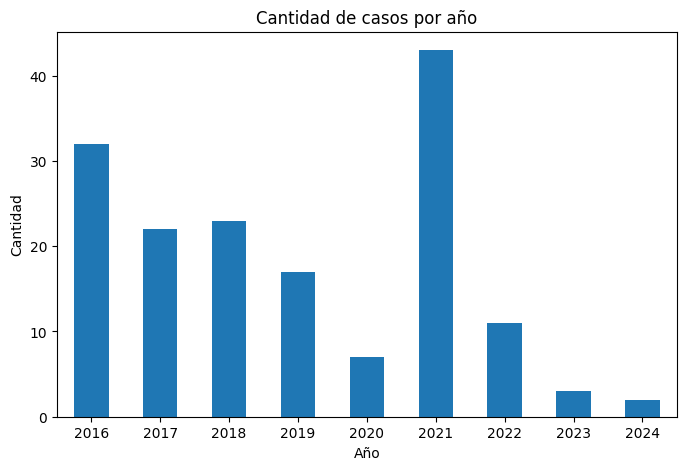

In [340]:
# Analizar cantidad de casos de rabia para ver si separamos los casos de rabia de la pandemia 2020 y 2021
import matplotlib.pyplot as plt

# Conteo de registros por año (ordenado)
conteo = gdf_rabies["anio"].value_counts().sort_index()

print(conteo)

# Gráfico de barras
conteo.plot(kind="bar", figsize=(8,5))
plt.title("Cantidad de casos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)  # Mantener etiquetas de años horizontales
plt.show()

# NOTA: No conviene separar lo datos de la pandemia, trabajaremos con todo

# Generar el grafo para TRAIN, VAL y TEST

In [502]:
import pandas as pd
import geopandas as gpd
import torch
from torch_geometric.data import HeteroData
from shapely.geometry import Point
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

#******************************************************
DATE = "08may2026"
RABIES_CASE_RADIUS = 200
CURRENT_YEAR = 2023
NEXT_YEAR = 2024
#******************************************************

# Cambiar a "EPSG:32719"
gdf_rabies_proj = gdf_rabies.to_crs("EPSG:32719")
gdf_economic_income_proj = gdf_economic_income.to_crs("EPSG:32719")
gdf_health_posts_proj = gdf_health_posts.to_crs("EPSG:32719")
gdf_water_channels_proj = gdf_water_channels.to_crs("EPSG:32719")

# --------------------------------------------
# CARGA DE DATOS (GeoDataFrames preprocesados):
# ----------------------------------------------
# - gdf_economic_income: areass como POLYGON
# - gdf_health_posts: centros de salud como POINT
# - gdf_water_channels: torrenteras como LINESTRING
# - gdf_rabies: casos de rabia como POINT + año
# ---------------------------

# Asegurar proyección métrica
areas = gdf_economic_income_proj.copy()
rabies_current_year = gdf_rabies_proj[gdf_rabies_proj["anio"] == CURRENT_YEAR].copy()
print(f"rabies_current_year: {len(rabies_current_year)}")
rabies_next_year    = gdf_rabies_proj[gdf_rabies_proj["anio"] == NEXT_YEAR].copy()
print(f"rabies_next_year: {len(rabies_next_year)}")
health_posts = gdf_health_posts_proj.copy()
water_channels = gdf_water_channels_proj.copy()

rabies_current_year: 3
rabies_next_year: 2


In [503]:
#--------------------------------------------------------------
# - Distancia minima a un caso de rabia (min_distance_rabies_case)
#   * NOTA: El codigo va aqui por que aqui recien sabemos cuales son los casos de rabia por año 
#--------------------------------------------------------------------
# Eliminar columnas que pueden causar problemas
rabies_current_year = rabies_current_year.drop(columns=["index_left", "index_right"], errors="ignore")
# Hacer sjoin_nearest, no es necesario lsuffix/rsuffix
# Calcula la distancia hasta el caso de rabia mas cercano y guarda esa distancia
gdf_nearest = areas.sjoin_nearest(
    rabies_current_year,
    how="left",
    distance_col="min_distance_rabies"
)
# Crear columna con el índice original de gdf_economic_income
gdf_nearest["poly_index"] = gdf_nearest.index
# Agrupar por cada polígono y quedarse solo con la distancia mínima en caso haya varias distancias
gdf_min_distance = gdf_nearest.groupby("poly_index")["min_distance_rabies"].min()
# Agregar al GeoDataFrame original
areas["min_distance_rabies"] = areas.index.map(gdf_min_distance)
stats = areas["min_distance_rabies"].describe()
print(stats)
#Se decide utilizar el radio de 100m ya que ahora estamos con superareas entonces si este valor es muy grandes ya su radios del caso de rabia seria mucho.
print("=== AREA_RABIES_CASE_RADIUS = 200 ===")

print("*************************************************************************************")
#-----------------------------------------------------
# - Cantidad de casos en el año (num_rabies_case_year)
#-----------------------------------------------------
# Spatial join: asigna casos a polígonos
rabies_with_area = gpd.sjoin(
    rabies_current_year, 
    areas, 
    how="left", 
    predicate="within"
)
# Contar casos por área
cases_per_area = rabies_with_area.groupby("index_right").size()
# Crear columna en areas
areas["num_rabies_case_year"] = areas.index.map(cases_per_area).fillna(0).astype(int)

print(areas["num_rabies_case_year"].value_counts())

# Casos que NO caen dentro de ninguna superárea
casos_fuera = rabies_with_area["index_right"].isna().sum()
print("Casos de rabia fuera de cualquier superárea:", casos_fuera)

areas.head()

count     432.000000
mean     2017.181767
std      1142.744365
min         0.000000
25%      1141.185104
50%      1913.871308
75%      2698.740070
max      5553.922846
Name: min_distance_rabies, dtype: float64
=== AREA_RABIES_CASE_RADIUS = 200 ===
*************************************************************************************
num_rabies_case_year
0    429
1      3
Name: count, dtype: int64
Casos de rabia fuera de cualquier superárea: 0


,cluster_global,geometry,block_id,ingreso_economico,ingreso_economico_num,cluster_local,area_id,min_distance_water_channel,min_distance_health_post,cluster_id,min_distance_rabies,num_rabies_case_year
0,B_0,"POLYGON ((225653.056 8189076.945, 225653.701 8...",1.4.54-1,B,2.0,0,area_1,993.200665,1005.833920,ZAMACOLA_06,1015.127781,0
1,B_1,"POLYGON ((224705.318 8188724.802, 224705.979 8...",1.4.93-10,B,2.0,1,area_2,2166.936229,2187.295812,ZAMACOLA_06,0.000000,1
2,B_2,"POLYGON ((225816.277 8188807.659, 225816.924 8...",1.4.54-12,B,2.0,2,area_3,1097.647130,1495.263033,ZAMACOLA_06,1091.488339,0
3,B_3,"POLYGON ((226285.220 8189510.007, 226285.876 8...",1.4.92-2,B,2.0,3,area_4,52.295476,949.851545,ZAMACOLA_06,1718.816690,0
4,B_4,"POLYGON ((225933.000 8189002.447, 225933.650 8...",1.4.54-10,B,2.0,4,area_5,673.060058,1313.227927,ZAMACOLA_06,1247.879766,0


In [504]:
'''
#--------------------------------------
# Crear la etiqueta del problema (solo toma en cuenta los casos de rabia dentro del poligono del area)
#--------------------------------------
# Eliminar columnas que pueden causar problemas
rabies_next_year = rabies_next_year.drop(columns=["index_left", "index_right"], errors="ignore")
# Spatial join: asigna cada caso de rabia del "año siguiente" al polígono en que cae
rabies_with_area_next = gpd.sjoin(
    rabies_next_year,
    areas,
    how="left",
    predicate="within"
)
# Contar casos por polígono
cases_per_area_next = rabies_with_area_next.groupby("index_right").size()
# Crear etiqueta binaria: 1 si hay >=1 caso, 0 si no
areas["label_rabies_next_year"] = areas.index.map(lambda i: 1 if i in cases_per_area_next.index else 0)

areas["label_rabies_next_year"].value_counts()
'''

'\n#--------------------------------------\n# Crear la etiqueta del problema (solo toma en cuenta los casos de rabia dentro del poligono del area)\n#--------------------------------------\n# Eliminar columnas que pueden causar problemas\nrabies_next_year = rabies_next_year.drop(columns=["index_left", "index_right"], errors="ignore")\n# Spatial join: asigna cada caso de rabia del "año siguiente" al polígono en que cae\nrabies_with_area_next = gpd.sjoin(\n    rabies_next_year,\n    areas,\n    how="left",\n    predicate="within"\n)\n# Contar casos por polígono\ncases_per_area_next = rabies_with_area_next.groupby("index_right").size()\n# Crear etiqueta binaria: 1 si hay >=1 caso, 0 si no\nareas["label_rabies_next_year"] = areas.index.map(lambda i: 1 if i in cases_per_area_next.index else 0)\n\nareas["label_rabies_next_year"].value_counts()\n'

In [505]:
#CREA ETIQUETAS
# Aseguramos que ambos están en el mismo CRS proyectado
areas = areas.to_crs("EPSG:32719")
rabies_next_year = rabies_next_year.to_crs("EPSG:32719")

# Eliminar columnas que pueden causar problemas
rabies_next_year = rabies_next_year.drop(columns=["index_left", "index_right"], errors="ignore")

# 1. Casos dentro del polígono (baseline)
rabies_with_area = gpd.sjoin(
    rabies_next_year,
    areas,
    how="inner",
    predicate="within"
)

# Inicializar etiquetas en 0
areas["label_rabies_next_year"] = 0
areas.loc[rabies_with_area["index_right"].unique(), "label_rabies_next_year"] = 1

print("Solo casos dentro del polígono:")
print(f"- {areas["label_rabies_next_year"].value_counts(dropna=False)}")

# 2. Casos con buffer de 100m
rabies_buffer = rabies_next_year.copy()
rabies_buffer["geometry"] = rabies_buffer.buffer(RABIES_CASE_RADIUS)

rabies_with_buffer = gpd.sjoin(
    areas,
    rabies_buffer,
    how="inner",
    predicate="intersects"
)

# Actualizar etiquetas: áreas que intersectan algún buffer
areas.loc[rabies_with_buffer.index.unique(), "label_rabies_next_year"] = 1

print(f"Casos dentro del polígono con {RABIES_CASE_RADIUS} metros de buffer:")
print(f"- {areas["label_rabies_next_year"].value_counts(dropna=False)}")



Solo casos dentro del polígono:
- label_rabies_next_year
0    431
1      1
Name: count, dtype: int64
Casos dentro del polígono con 200 metros de buffer:
- label_rabies_next_year
0    423
1      9
Name: count, dtype: int64


In [506]:
# ---------------------------
# PARÁMETROS CONFIGURABLES
# ---------------------------

# Escogemos el radio de 250 por que cubre la mayoría de las áreas (aproximadamente 50% y 70%) y no es demasiado grande
AREA_WATER_CHANNEL_RADIUS = 50 #superareas=50 #250 # podriamos probar luego con 300

# Se decide utilizar el radio de 2000m por que segun lo datos obtenido cubre alrededor del 60–70% de las áreas (hasta el tercer cuartil)
AREA_HEALTH_POSTS_RADIUS = 2000

# Puede ser mayor que el RABIES_CASE_RADIUS ya que este solo es una relacion no es la etiqueta
AREA_RABIES_CASE_RADIUS = 400 #superareas=200 #400 

AREA_NEIGHBOR_RADIUS = 100  # radio en metros para definir los VECINOS entre AREAS

In [507]:
# ---------------------------------
# PREPARAR GEOMETRÍA PARA OPTIMIZACIÓN
# ---------------------------------

# Centroide de cada superárea (en metros para mayor precisión)
areas_proj = areas.to_crs(epsg=3857)
areas["centroid"] = areas_proj.centroid.to_crs(epsg=4326)

# (Opcional pero recomendado) área en m²
areas["area_m2"] = areas_proj.area

# Verificación rápida
print("Centroides y áreas añadidos:")
print(areas[["area_id", "centroid", "area_m2"]].head())

Centroides y áreas añadidos:
  area_id                     centroid        area_m2
0  area_1  POINT (-71.56535 -16.36235)  108588.337836
1  area_2  POINT (-71.57549 -16.36901)   81613.659134
2  area_3  POINT (-71.56479 -16.36657)   61264.880523
3  area_4  POINT (-71.55774 -16.36283)  634230.568105
4  area_5  POINT (-71.56226 -16.36544)  158561.383035


### CREAR NODOS

In [508]:
# ---------------------------
# CREAR GRAFO HETEROGÉNEO
# ---------------------------

data = HeteroData()

# NODO PUESTO DE SALUD
#-----------------------
# No guardamos lat/long como features
# Guardamos cluster y n_microred
# A pesar que no tenga ninguna feature aporta como ancla en el modelo

hp_feature_columns = ["cluster", "n_microred"]
scaler = MinMaxScaler()
health_post_features = scaler.fit_transform(health_posts[hp_feature_columns])
data["health_post"].x = torch.tensor(health_post_features, dtype=torch.float)
data['health_post'].feature_columns = hp_feature_columns
data["health_post"].name = health_posts["name"].tolist()
data["health_post"].node_index = health_posts.index.to_list()

# NODO TORRENTERA
#-----------------------
num_wc = len(water_channels)
data["water_channel"].x = torch.zeros((num_wc, 1))  # placeholder
data["water_channel"].ident = water_channels["ident"].tolist()
data["water_channel"].node_index = water_channels.index.to_list()  # <-- guardar índices

# NODO CASOS DE RABIA
#-----------------------
num_rc = len(rabies_current_year)
data["rabies_case"].x = torch.zeros((num_rc, 1))  # placeholder
data["rabies_case"].name = rabies_current_year["name"].tolist()
data["rabies_case"].node_index = rabies_current_year.index.to_list()  # <-- guardar índices

# NODO AREA
#-----------------------
# - Distancia minima al puesto de salud
# - Distancia minima a la torrentera
# - Distancia minima a un caso de rabia
# - Cantidad de casos en el año

# Normalizar
a_feature_columns = ["ingreso_economico_num", 
                     "min_distance_water_channel",
                     "min_distance_health_post",
                     "min_distance_rabies",
                     "num_rabies_case_year",
                     "area_m2" ]
scaler = MinMaxScaler()
area_features = scaler.fit_transform(areas[a_feature_columns])

data["area"].x = torch.tensor(area_features, dtype=torch.float)
data['area'].feature_columns = a_feature_columns
data["area"].area_id = areas["area_id"].tolist() # Me conviene guardarlo para poder despues relacionar los resultados 
data["area"].node_index = areas.index.to_list()  # <-- Aquí guardar índices reales

## OJO: Solo por esta vez, porque esto debe de manipularse en el modelo
# Crear y guardar etiquetas binarias directamente
#col_idx = feature_columns.index("num_rabies_cases_in_area")
#num_cases_tensor = data['area'].x[:, col_idx]
#data['area'].y = (num_cases_tensor > 0).long()
data['area'].y = torch.tensor(areas[["label_rabies_next_year"]].values, dtype=torch.float) # FLOAT por que BCEWithLogitsLoss

num_pos = torch.sum(data['area'].y).item()
num_total = data['area'].y.size(0)
num_neg = num_total - num_pos
print(f"Positivos (1): {num_pos}")
print(f"Negativos (0): {num_neg}")

Positivos (1): 9.0
Negativos (0): 423.0


In [509]:
# COMPROBACION DE DATOS
## PARA PROPOSITOS DE VISUALIZACION Y VER QUE TODO VAYA BIEN
#
print("------------------------------------------------------------------")
print("*****************  df_preview_health_post  *************************")
print("------------------------------------------------------------------")
df_preview_health_post = pd.DataFrame({
    "name": data["health_post"].name[:5],
    "node_index": data["health_post"].node_index[:5],
    "cluster": data["health_post"].x[:, 0].tolist(),
    "n_microred": data["health_post"].x[:, 1].tolist()
})

print(df_preview_health_post.head())

print("------------------------------------------------------------------")
print("*****************  df_preview_area  *************************")
print("------------------------------------------------------------------")
df_preview_area = pd.DataFrame({
    "area_id": data["area"].area_id,   # todos
    "node_index": data["area"].node_index,  # todos
    "ingreso_economico_num": data["area"].x[:, 0].tolist(),
    "min_distance_water_channel": data["area"].x[:, 1].tolist(),
    "min_distance_health_post": data["area"].x[:, 2].tolist(),
    "min_distance_rabies": data["area"].x[:, 3].tolist(),
    "num_rabies_case_year": data["area"].x[:, 4].tolist(),
    "area_m2": data["area"].x[:, 5].tolist(),
})

df_preview_area.head(15) # Se miran datos diferentes por que ya se normalizaron los datos

------------------------------------------------------------------
*****************  df_preview_health_post  *************************
------------------------------------------------------------------
                      name  node_index  cluster  n_microred
0  C.S. MARITZA CAMPO DIAZ           0      0.0         0.0
1    P.S. CIUDAD MUNICIPAL           1      1.0         0.0
2            P.S. PERUARBO           2      0.0         0.0
3            P.S. NAZARENO           3      0.5         0.0
------------------------------------------------------------------
*****************  df_preview_area  *************************
------------------------------------------------------------------


,area_id,node_index,ingreso_economico_num,min_distance_water_channel,min_distance_health_post,min_distance_rabies,num_rabies_case_year,area_m2
0,area_1,0,0.000000,0.458343,0.197132,0.182777,0.0,0.169823
1,area_2,1,0.000000,1.000000,0.428686,0.000000,1.0,0.127220
2,area_3,2,0.000000,0.506543,0.293055,0.196526,0.0,0.095082
3,area_4,3,0.000000,0.024133,0.186160,0.309478,0.0,1.000000
4,area_5,4,0.000000,0.310604,0.257378,0.224684,0.0,0.248748
5,area_6,5,0.333333,0.000426,0.015471,0.117777,0.0,0.148646
6,area_7,6,0.333333,0.306611,0.006029,0.386740,0.0,0.157253
7,area_8,7,0.333333,0.010210,0.002768,0.089087,0.0,0.116634
8,area_9,8,0.333333,0.472009,0.244840,0.364496,0.0,0.176797
9,area_10,9,0.333333,0.099193,0.030703,0.433379,0.0,0.240437


In [510]:
# Ejemplo para ver si estan bien los datos
df_preview_area["ingreso_economico_num"].value_counts()

ingreso_economico_num
1.000000    299
0.666667    106
0.333333     22
0.000000      5
Name: count, dtype: int64

### CREAR RELACIONES (ARISTAS)

In [511]:
from shapely.geometry import box

# ---------------------------
# area ↔ area (vecinas por distancia entre centroides)
# ---------------------------
# Asegurarse de estar en CRS métrico
assert areas.crs.is_projected, "Reproyecta a CRS en metros antes de calcular distancias."

# Generar relaciones de vecindad
edges = []
distances = []

# Crear índice espacial
sindex = areas.sindex

for i, geom in enumerate(areas.geometry):
    # Bounding box expandida por el radio
    bbox = box(*geom.bounds).buffer(AREA_NEIGHBOR_RADIUS).bounds
    
    # Posibles vecinos (candidatos dentro de la bbox)
    candidate_idx = list(sindex.intersection(bbox))
    
    for j in candidate_idx:
        if i == j:
            continue  # evitar self-loop
        d = geom.distance(areas.geometry.iloc[j])
        if d <= AREA_NEIGHBOR_RADIUS:
            edges.append([i, j])
            distances.append(d)

# Convertir a tensores PyTorch
edge_index = torch.tensor(edges, dtype=torch.long).T   # shape [2, num_edges]
edge_attr  = torch.tensor(distances, dtype=torch.float).unsqueeze(1)  # shape [num_edges, 1]

distances = np.array(edge_attr).reshape(-1,1)
scaler = MinMaxScaler()
edge_attr_norm = scaler.fit_transform(distances)

# Guardar en data
data["area", "neighbor_of", "area"].edge_index = edge_index
data[("area", "neighbor_of", "area")].edge_attr = torch.tensor(edge_attr_norm, dtype=torch.float)

# Revisar si todas las aristas tienen su inversa
edges_set = set(map(tuple, edges))
missing = [(i, j) for (i, j) in edges_set if (j, i) not in edges_set]

print(f"Aristas totales: {len(edges_set)}")
print(f"Aristas sin inversa: {len(missing)}")#Si missing = 0 → tu grafo ya es bidireccional.

Aristas totales: 2018
Aristas sin inversa: 0


/tmp/ipykernel_18260/1465182308.py:35: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  distances = np.array(edge_attr).reshape(-1,1)


In [512]:
# ---------------------------
# area → Torrenteras (con distancia como atributo)
# ---------------------------
edges_area_wc = []
edges_wc_area = []
distances = []

# Índices espaciales
sindex_area = areas.sindex
sindex_wc = water_channels.sindex

for i, geom_area in enumerate(areas.geometry):
    # bounding box expandida por el radio
    bbox = box(*geom_area.bounds).buffer(AREA_WATER_CHANNEL_RADIUS).bounds
    
    # candidatos: torrenteras dentro de la bbox
    candidate_idx = list(sindex_wc.intersection(bbox))
    
    for j in candidate_idx:
        geom_wc = water_channels.geometry.iloc[j]
        d = geom_area.distance(geom_wc)
        if d <= AREA_WATER_CHANNEL_RADIUS:
            edges_area_wc.append([i, j])
            edges_wc_area.append([j, i])
            distances.append(d)

# Convertir a tensores
edge_index_area_wc = torch.tensor(edges_area_wc, dtype=torch.long).T
edge_index_wc_area = torch.tensor(edges_wc_area, dtype=torch.long).T

# Normalizar distancias
scaler = MinMaxScaler()
edge_attr_norm = scaler.fit_transform(np.array(distances).reshape(-1, 1))
edge_attr_tensor = torch.tensor(edge_attr_norm, dtype=torch.float)

# Guardar en HeteroData
data["area", "a_near_wc", "water_channel"].edge_index = edge_index_area_wc
data["area", "a_near_wc", "water_channel"].edge_attr  = edge_attr_tensor
# Como no vamos a utilizar el nodo torrentera como TARGET no es necesario hacerlo bidireccional
data["water_channel", "wc_near_a", "area"].edge_index = edge_index_wc_area
data["water_channel", "wc_near_a", "area"].edge_attr  = edge_attr_tensor 

In [513]:
# ---------------------------
# area → Puesto de salud más cercano y pone la distancia como atributo
# ---------------------------
edges_area_hp = []
edges_hp_area = []
distances = []

# Índices espaciales
sindex_area = areas.sindex
sindex_hp   = health_posts.sindex

for i, geom_area in enumerate(areas.geometry):
    # bounding box expandida por el radio
    bbox = box(*geom_area.bounds).buffer(AREA_HEALTH_POSTS_RADIUS).bounds
    
    # candidatos: puestos dentro de la bbox
    candidate_idx = list(sindex_hp.intersection(bbox))
    
    for j in candidate_idx:
        geom_hp = health_posts.geometry.iloc[j]
        d = geom_area.distance(geom_hp)
        if d <= AREA_HEALTH_POSTS_RADIUS:
            edges_area_hp.append([i, j])
            edges_hp_area.append([j, i])
            distances.append(d)

# Convertir a tensores
edge_index_area_hp = torch.tensor(edges_area_hp, dtype=torch.long).T
edge_index_hp_area = torch.tensor(edges_hp_area, dtype=torch.long).T

# Normalizar distancias
scaler = MinMaxScaler()
edge_attr_norm = scaler.fit_transform(np.array(distances).reshape(-1, 1))
edge_attr_tensor = torch.tensor(edge_attr_norm, dtype=torch.float)

# Guardar en HeteroData
data["area", "reports_to", "health_post"].edge_index = edge_index_area_hp
data["area", "reports_to", "health_post"].edge_attr  = edge_attr_tensor

data["health_post", "receives_reports", "area"].edge_index = edge_index_hp_area
data["health_post", "receives_reports", "area"].edge_attr  = edge_attr_tensor

In [514]:
# ---------------------------
# 🦠 Caso de rabia → area (sjoin espacial)
# ---------------------------
edges_area_rc = []
edges_rc_area = []
distances = []

# Índices espaciales
sindex_area = areas.sindex
sindex_rc = rabies_current_year.sindex

for i, geom_area in enumerate(areas.geometry):
    # Bounding box expandida por el radio
    bbox = box(*geom_area.bounds).buffer(AREA_RABIES_CASE_RADIUS).bounds
    
    # candidatos: casos de rabia dentro de la bbox
    candidate_idx = list(sindex_rc.intersection(bbox))
    
    for j in candidate_idx:
        geom_rc = rabies_current_year.geometry.iloc[j]
        d = geom_area.distance(geom_rc)
        if d <= AREA_RABIES_CASE_RADIUS:
            # Arista area → rabies_case
            edges_area_rc.append([i, j])
            # Arista rabies_case → area
            edges_rc_area.append([j, i])
            distances.append(d)

# Convertir a tensores
edge_index_area_rc = torch.tensor(edges_area_rc, dtype=torch.long).T
edge_index_rc_area = torch.tensor(edges_rc_area, dtype=torch.long).T

# Normalizar distancias
scaler = MinMaxScaler()
edge_attr_norm = scaler.fit_transform(np.array(distances).reshape(-1, 1))
edge_attr_tensor = torch.tensor(edge_attr_norm, dtype=torch.float)

# Guardar en HeteroData
data["area", "a_near_rc", "rabies_case"].edge_index = edge_index_area_rc
data["area", "a_near_rc", "rabies_case"].edge_attr  = edge_attr_tensor

data["rabies_case", "rb_near_a", "area"].edge_index = edge_index_rc_area
data["rabies_case", "rb_near_a", "area"].edge_attr  = edge_attr_tensor

In [515]:
# PARA VERIFICAR LA CANTIDAD DE NODOS Y ARISTAS
#print("Nodos en 'rabies_case':", data["rabies_case"].num_nodes)
print("Nodos en 'area':", data["area"].num_nodes)
print("Relaciones y número de aristas:")
for etype in data.edge_types:
    edge_storage = data[etype]
    print(f"{etype}: num_edges={getattr(edge_storage, 'num_edges', 'unknown')}")

Nodos en 'area': 432
Relaciones y número de aristas:
('area', 'neighbor_of', 'area'): num_edges=2018
('area', 'a_near_wc', 'water_channel'): num_edges=321
('water_channel', 'wc_near_a', 'area'): num_edges=321
('area', 'reports_to', 'health_post'): num_edges=359
('health_post', 'receives_reports', 'area'): num_edges=359
('area', 'a_near_rc', 'rabies_case'): num_edges=25
('rabies_case', 'rb_near_a', 'area'): num_edges=25


In [516]:
areas.head()

,cluster_global,geometry,block_id,ingreso_economico,ingreso_economico_num,cluster_local,area_id,min_distance_water_channel,min_distance_health_post,cluster_id,min_distance_rabies,num_rabies_case_year,label_rabies_next_year,centroid,area_m2
0,B_0,"POLYGON ((225653.056 8189076.945, 225653.701 8...",1.4.54-1,B,2.0,0,area_1,993.200665,1005.833920,ZAMACOLA_06,1015.127781,0,0,POINT (-71.56535 -16.36235),108588.337836
1,B_1,"POLYGON ((224705.318 8188724.802, 224705.979 8...",1.4.93-10,B,2.0,1,area_2,2166.936229,2187.295812,ZAMACOLA_06,0.000000,1,0,POINT (-71.57549 -16.36901),81613.659134
2,B_2,"POLYGON ((225816.277 8188807.659, 225816.924 8...",1.4.54-12,B,2.0,2,area_3,1097.647130,1495.263033,ZAMACOLA_06,1091.488339,0,0,POINT (-71.56479 -16.36657),61264.880523
3,B_3,"POLYGON ((226285.220 8189510.007, 226285.876 8...",1.4.92-2,B,2.0,3,area_4,52.295476,949.851545,ZAMACOLA_06,1718.816690,0,0,POINT (-71.55774 -16.36283),634230.568105
4,B_4,"POLYGON ((225933.000 8189002.447, 225933.650 8...",1.4.54-10,B,2.0,4,area_5,673.060058,1313.227927,ZAMACOLA_06,1247.879766,0,0,POINT (-71.56226 -16.36544),158561.383035


In [517]:
# ---------------------------
# GUARDAR EL GRAFO
# ---------------------------
torch.save(
    data,
    f"/home/pantro/Documentos/GITHUB/rabies-graph-neural-model/results/asonam/heterograph_{CURRENT_YEAR}_{RABIES_CASE_RADIUS}_superareas_{DATE}.pt"
)

# Guardando la Geometria del area
areas_export = areas[["area_id", "geometry", "cluster_id"]].copy()

areas_export["centroid_x"] = areas["centroid"].x
areas_export["centroid_y"] = areas["centroid"].y

areas_export.to_file(
    f"/home/pantro/Documentos/GITHUB/rabies-graph-neural-model/results/asonam/areas_{DATE}.gpkg",
    driver="GPKG"
)

print(f"✅ Grafo heterogéneo del {CURRENT_YEAR} guardado")

✅ Grafo heterogéneo del 2023 guardado


In [518]:
#pip install networkx

## Cargando el grafo guardado

In [519]:
'''
import torch

# Cargar el grafo
data = torch.load("/home/pantro/Documentos/GITHUB/rabies-graph-neural-model/zamacola_heterograph_fase3.pt", weights_only=False)

print("✅ Grafo heterogéneo cargado correctamente")
print(isinstance(data, HeteroData))  # Debería imprimir: True
print(data)
'''

'\nimport torch\n\n# Cargar el grafo\ndata = torch.load("/home/pantro/Documentos/GITHUB/rabies-graph-neural-model/zamacola_heterograph_fase3.pt", weights_only=False)\n\nprint("✅ Grafo heterogéneo cargado correctamente")\nprint(isinstance(data, HeteroData))  # Debería imprimir: True\nprint(data)\n'

# Guardar en formato para Neo4j

In [520]:
'''
import torch
import pandas as pd
import os

def heterodata_to_neo4j_csv(data, output_dir="neo4j_csv"):
    os.makedirs(output_dir, exist_ok=True)

    # Guardar nodos
    for node_type in data.node_types:
        node_data = data[node_type]

        # Asegurarse de que haya atributos
        if hasattr(node_data, 'x') and node_data.x is not None:
            df = pd.DataFrame(node_data.x.cpu().numpy())
            df.columns = [f"attr{i}" for i in range(df.shape[1])]
        else:
            num_nodes = data[node_type].num_nodes
            df = pd.DataFrame(index=range(num_nodes))  # Nodo sin atributos

        # Agregar columna de ID (requerida por Neo4j)
        df[f"{node_type}_id"] = df.index
        df.to_csv(os.path.join(output_dir, f"nodes_{node_type}.csv"), index=False)
        print(f"Guardado nodos: {node_type} -> {df.shape}")

    # Guardar aristas
    for edge_type in data.edge_types:
        src_type, rel_type, dst_type = edge_type
        edge_index = data[edge_type].edge_index.cpu().numpy()

        edge_df = pd.DataFrame({
            "source": edge_index[0],
            "target": edge_index[1],
            "type": rel_type,
            "source_type": src_type,
            "target_type": dst_type
        })

        # Agregar atributos de aristas si existen
        if 'edge_attr' in data[edge_type]:
            edge_attrs = data[edge_type]['edge_attr'].cpu().numpy()
            edge_attr_df = pd.DataFrame(edge_attrs)
            edge_df = pd.concat([edge_df, edge_attr_df], axis=1)

        filename = f"edges_{src_type}_{rel_type}_{dst_type}.csv"
        edge_df.to_csv(os.path.join(output_dir, filename), index=False)
        print(f"Guardado aristas: {edge_type} -> {edge_df.shape}")

    print("\n✅ Exportación completa. Los archivos están en:", os.path.abspath(output_dir))


# Llamar a la función
heterodata_to_neo4j_csv(data)
'''

'\nimport torch\nimport pandas as pd\nimport os\n\ndef heterodata_to_neo4j_csv(data, output_dir="neo4j_csv"):\n    os.makedirs(output_dir, exist_ok=True)\n\n    # Guardar nodos\n    for node_type in data.node_types:\n        node_data = data[node_type]\n\n        # Asegurarse de que haya atributos\n        if hasattr(node_data, \'x\') and node_data.x is not None:\n            df = pd.DataFrame(node_data.x.cpu().numpy())\n            df.columns = [f"attr{i}" for i in range(df.shape[1])]\n        else:\n            num_nodes = data[node_type].num_nodes\n            df = pd.DataFrame(index=range(num_nodes))  # Nodo sin atributos\n\n        # Agregar columna de ID (requerida por Neo4j)\n        df[f"{node_type}_id"] = df.index\n        df.to_csv(os.path.join(output_dir, f"nodes_{node_type}.csv"), index=False)\n        print(f"Guardado nodos: {node_type} -> {df.shape}")\n\n    # Guardar aristas\n    for edge_type in data.edge_types:\n        src_type, rel_type, dst_type = edge_type\n       

# Armar datos para el random forest

In [521]:
from shapely.ops import nearest_points

In [522]:
'''
# TRAIN_VAL
rf_gdf_rabies = gdf_rabies_train_val.copy()

# Cambiar a "EPSG:32719"
rf_gdf_rabies_proj = rf_gdf_rabies.to_crs("EPSG:32719")
rf_gdf_economic_income_proj = gdf_economic_income.to_crs("EPSG:32719")
rf_gdf_health_posts_proj = gdf_health_posts.to_crs("EPSG:32719")
rf_gdf_water_channels_proj = gdf_water_channels.to_crs("EPSG:32719")
'''

'\n# TRAIN_VAL\nrf_gdf_rabies = gdf_rabies_train_val.copy()\n\n# Cambiar a "EPSG:32719"\nrf_gdf_rabies_proj = rf_gdf_rabies.to_crs("EPSG:32719")\nrf_gdf_economic_income_proj = gdf_economic_income.to_crs("EPSG:32719")\nrf_gdf_health_posts_proj = gdf_health_posts.to_crs("EPSG:32719")\nrf_gdf_water_channels_proj = gdf_water_channels.to_crs("EPSG:32719")\n'

In [523]:
'''
areas = rf_gdf_economic_income_proj.copy()

areas["centroid"] = areas.geometry.centroid

# One-hot encoding ingreso económico
areas = pd.get_dummies(areas, columns=["ingreso_economico"], prefix="ingreso")

# Casos de rabia dentro de la area
areas["num_rabies_cases_in_area"] = areas.geometry.apply(
    lambda poly: rabies[rabies.within(poly)].shape[0]
)


# Crear una lista con las geometrías de los puestos de salud (POINT)
health_points = rf_gdf_health_posts_proj.geometry.unary_union
# Calcular la distancia mínima a cada area
areas['dist_to_nearest_health_post'] = areas.geometry.apply(
    lambda g: g.distance(nearest_points(g, health_points)[1])
)

# Parámetro: distancia máxima para considerar la torrenteras como relevantes
MAX_DIST = 500  # en metros
# Unimos las torrenteras en una sola geometría multiparte
torrenteras_geom = rf_gdf_water_channels_proj.geometry.unary_union
# Calcular distancia a torrenteras (si > MAX_DIST => 9999)
areas['dist_to_nearest_water_channel'] = areas.geometry.apply(
    lambda g: g.distance(torrenteras_geom) if g.distance(torrenteras_geom) <= MAX_DIST else 9999
)

# Distancia al caso de rabia más cercano en 100 m
def min_dist_to_case(poly_centroid, rabies_points, max_dist):
    distances = rabies_points.distance(poly_centroid)
    close = distances[distances <= max_dist]
    return close.min() if not close.empty else np.nan
areas["min_dist_to_rabies_case"] = areas["centroid"].apply(
    lambda p: min_dist_to_case(p, rabies.geometry, AREA_RABIES_CASE_RADIUS)
)
# Rellenar NaN con un valor alto para que redes neuronales lo manejen mejor
areas["min_dist_to_rabies_case"] = areas["min_dist_to_rabies_case"].fillna(9999)


# Creando etiqueta Y
areas['y'] = (areas['num_rabies_cases_in_area'] > 0).astype(int)

print(areas['y'].value_counts())
areas.head()
'''

'\nareas = rf_gdf_economic_income_proj.copy()\n\nareas["centroid"] = areas.geometry.centroid\n\n# One-hot encoding ingreso económico\nareas = pd.get_dummies(areas, columns=["ingreso_economico"], prefix="ingreso")\n\n# Casos de rabia dentro de la area\nareas["num_rabies_cases_in_area"] = areas.geometry.apply(\n    lambda poly: rabies[rabies.within(poly)].shape[0]\n)\n\n\n# Crear una lista con las geometrías de los puestos de salud (POINT)\nhealth_points = rf_gdf_health_posts_proj.geometry.unary_union\n# Calcular la distancia mínima a cada area\nareas[\'dist_to_nearest_health_post\'] = areas.geometry.apply(\n    lambda g: g.distance(nearest_points(g, health_points)[1])\n)\n\n# Parámetro: distancia máxima para considerar la torrenteras como relevantes\nMAX_DIST = 500  # en metros\n# Unimos las torrenteras en una sola geometría multiparte\ntorrenteras_geom = rf_gdf_water_channels_proj.geometry.unary_union\n# Calcular distancia a torrenteras (si > MAX_DIST => 9999)\nareas[\'dist_to_nearest_

In [524]:
'''
# Eliminando centroide
areas.drop(columns=['centroid'], inplace=True)

areas.to_file('rf_areas.gpkg', driver='GPKG')
'''

"\n# Eliminando centroide\nareas.drop(columns=['centroid'], inplace=True)\n\nareas.to_file('rf_areas.gpkg', driver='GPKG')\n"